Data path: /Users/sreeragm/fraud-decision-engine/data/creditcard.csv
Reports path: /Users/sreeragm/fraud-decision-engine/reports

Dataset: (284807, 31)

FROZEN DECISION POLICY

Model: Class Weighted XGBoost
Threshold: 0.56

Rebuilding Class Weighted XGBoost...
Final model rebuilt.

Creating SHAP TreeExplainer...
SHAP explainer ready.

Calculating SHAP values...
SHAP calculation complete.

INVESTIGATOR CASE ENGINE

Total test transactions: 42722
Transactions requiring review: 45
Transactions approved: 42677

TOP 20 INVESTIGATION CASES
 Transaction_Index  Amount  Fraud_Probability Risk_Band Investigation_Priority Top_Risk_Driver  Top_Risk_SHAP  Actual_Class
            263324  127.14           0.999994  CRITICAL            P1 — URGENT             V14       4.949313             1
            262559    4.69           0.999990  CRITICAL            P1 — URGENT             V14       5.324026             1
            247995   51.37           0.999990  CRITICAL            P1 — URGENT          

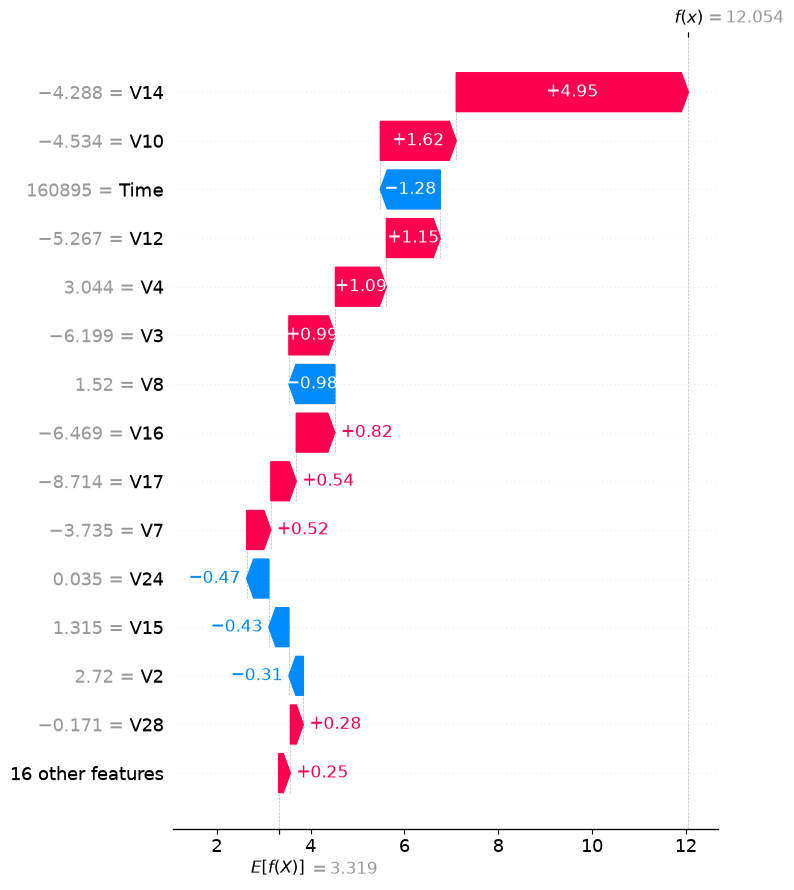

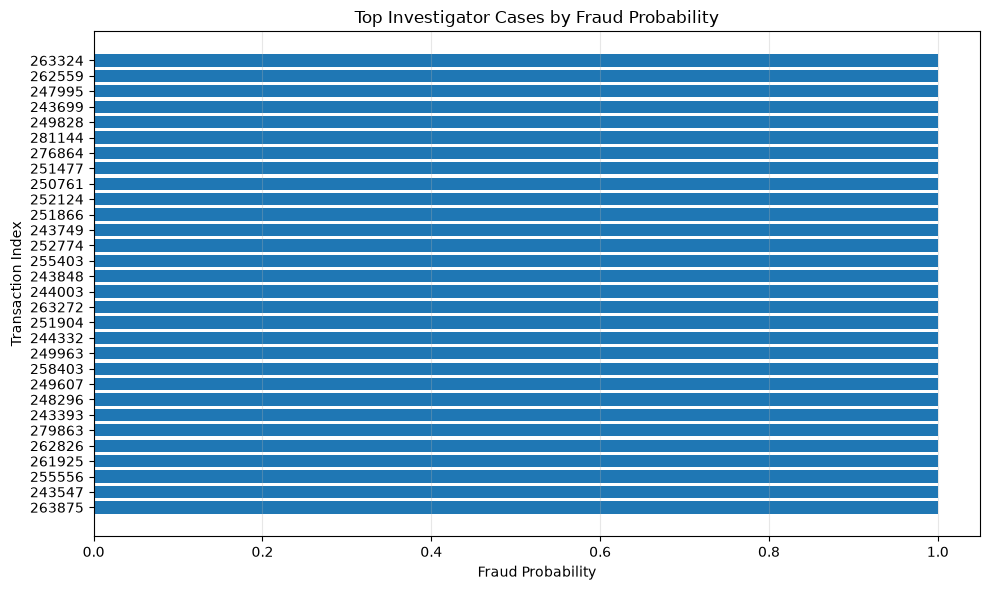


PHASE 10 COMPLETE

Generated files:
✓ investigator_case_queue_all.csv
✓ investigator_review_queue.csv
✓ investigator_decision_performance.csv
✓ investigator_risk_band_performance.csv
✓ investigator_reason_code_frequency.csv
✓ sample_investigator_case.json
✓ sample_investigator_case_waterfall.png
✓ investigator_case_priority.png
✓ investigator_case_report.txt

INVESTIGATOR ENGINE SUMMARY

Model: Class Weighted XGBoost
Frozen threshold: 0.56
Review cases: 45
Approved: 42677

Highest-risk transaction:
Transaction_Index                            263324
Amount                                       127.14
Fraud_Probability                          0.999994
Risk_Band                                  CRITICAL
Investigation_Priority                  P1 — URGENT
Reason_Codes              V14 | V10 | V12 | V4 | V3
Actual_Class                                      1


Phase 10 converts model predictions into investigator-ready cases with SHAP reason codes.

Next: Phase 11 — PSI / Out-of-Time Sta

In [1]:
# ============================================================
# PHASE 10 — INVESTIGATOR CASE ENGINE
# Credit Card Fraud Decision Engine
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import shap

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE


# ============================================================
# 1. PATHS
# ============================================================

DATA_PATH = Path("../data/creditcard.csv")
REPORTS_PATH = Path("../reports")

REPORTS_PATH.mkdir(parents=True, exist_ok=True)

print("Data path:", DATA_PATH.resolve())
print("Reports path:", REPORTS_PATH.resolve())


# ============================================================
# 2. LOAD DATA
# ============================================================

df = pd.read_csv(DATA_PATH)

df = df.sort_values(
    "Time"
).reset_index(drop=True)

print("\nDataset:", df.shape)


# ============================================================
# 3. TEMPORAL SPLIT
# ============================================================

n = len(df)

train_end = int(n * 0.70)

validation_end = int(n * 0.85)

train = df.iloc[
    :train_end
].copy()

validation = df.iloc[
    train_end:validation_end
].copy()

test = df.iloc[
    validation_end:
].copy()


# ============================================================
# 4. FEATURES / TARGET
# ============================================================

X_train = train.drop(
    columns=["Class"]
)

y_train = train["Class"]

X_validation = validation.drop(
    columns=["Class"]
)

y_validation = validation["Class"]

X_test = test.drop(
    columns=["Class"]
)

y_test = test["Class"]


# ============================================================
# 5. LOAD FROZEN DECISION POLICY
# ============================================================

policy_path = (
    REPORTS_PATH /
    "frozen_decision_policy.json"
)

if not policy_path.exists():

    raise FileNotFoundError(
        "\nCould not find frozen_decision_policy.json.\n"
        "Run Phase 9 first."
    )


with open(
    policy_path,
    "r"
) as f:

    policy = json.load(f)


selected_model_name = (
    policy["model"]
)

frozen_threshold = float(
    policy["threshold"]
)


print("\n" + "=" * 70)
print("FROZEN DECISION POLICY")
print("=" * 70)

print(
    "\nModel:",
    selected_model_name
)

print(
    "Threshold:",
    frozen_threshold
)


# ============================================================
# 6. TRAIN THE SAME FINAL MODEL
#
# We reproduce the model selected in Phase 9.
# ============================================================

if selected_model_name == "SMOTE XGBoost":

    print(
        "\nRebuilding SMOTE XGBoost..."
    )

    smote = SMOTE(
        sampling_strategy=1.0,
        random_state=42
    )

    X_train_final, y_train_final = (
        smote.fit_resample(
            X_train,
            y_train
        )
    )

    final_model = XGBClassifier(

        n_estimators=500,

        max_depth=6,

        learning_rate=0.05,

        subsample=0.8,

        colsample_bytree=0.8,

        objective="binary:logistic",

        eval_metric="aucpr",

        scale_pos_weight=1,

        tree_method="hist",

        random_state=42,

        n_jobs=-1
    )

    final_model.fit(
        X_train_final,
        y_train_final
    )

else:

    print(
        "\nRebuilding Class Weighted XGBoost..."
    )

    negative_count = (
        y_train == 0
    ).sum()

    positive_count = (
        y_train == 1
    ).sum()

    scale_pos_weight = (
        negative_count /
        positive_count
    )

    final_model = XGBClassifier(

        n_estimators=500,

        max_depth=6,

        learning_rate=0.05,

        subsample=0.8,

        colsample_bytree=0.8,

        objective="binary:logistic",

        eval_metric="aucpr",

        scale_pos_weight=
            scale_pos_weight,

        tree_method="hist",

        random_state=42,

        n_jobs=-1
    )

    final_model.fit(
        X_train,
        y_train
    )


print(
    "Final model rebuilt."
)


# ============================================================
# 7. SCORE TEST DATA
# ============================================================

test_probability = (
    final_model.predict_proba(
        X_test
    )[:, 1]
)


test_decision = np.where(
    test_probability >= frozen_threshold,
    "REVIEW",
    "APPROVE"
)


# ============================================================
# 8. BUILD SHAP EXPLAINER
# ============================================================

print(
    "\nCreating SHAP TreeExplainer..."
)

explainer = shap.TreeExplainer(
    final_model
)

print(
    "SHAP explainer ready."
)


# ============================================================
# 9. CALCULATE SHAP VALUES FOR TEST SET
# ============================================================

print(
    "\nCalculating SHAP values..."
)

shap_values = explainer(
    X_test
)

print(
    "SHAP calculation complete."
)


# ============================================================
# 10. BASELINE VALUE
# ============================================================

expected_value = (
    shap_values.base_values
)


# ============================================================
# 11. CREATE INVESTIGATOR CASE DATA
# ============================================================

case_records = []


for position in range(
    len(X_test)
):

    row_index = X_test.index[
        position
    ]

    probability = float(
        test_probability[position]
    )

    decision = (
        test_decision[position]
    )

    actual_class = int(
        y_test.iloc[position]
    )

    transaction = X_test.iloc[
        position
    ]


    # --------------------------------------------------------
    # SHAP VALUES
    # --------------------------------------------------------

    transaction_shap = (
        shap_values.values[position]
    )


    shap_df = pd.DataFrame({

        "Feature":
            X_test.columns,

        "Feature_Value":
            transaction.values,

        "SHAP_Value":
            transaction_shap

    })


    shap_df[
        "Absolute_SHAP"
    ] = shap_df[
        "SHAP_Value"
    ].abs()


    shap_df = shap_df.sort_values(
        "Absolute_SHAP",
        ascending=False
    ).reset_index(
        drop=True
    )


    # --------------------------------------------------------
    # TOP POSITIVE FRAUD DRIVERS
    # --------------------------------------------------------

    positive_drivers = (
        shap_df[
            shap_df["SHAP_Value"] > 0
        ]
        .sort_values(
            "SHAP_Value",
            ascending=False
        )
        .head(5)
    )


    # --------------------------------------------------------
    # TOP NEGATIVE FRAUD DRIVERS
    # --------------------------------------------------------

    negative_drivers = (
        shap_df[
            shap_df["SHAP_Value"] < 0
        ]
        .sort_values(
            "SHAP_Value",
            ascending=True
        )
        .head(3)
    )


    # --------------------------------------------------------
    # CREATE HUMAN-READABLE REASON CODES
    # --------------------------------------------------------

    reason_codes = []

    for _, driver in (
        positive_drivers.iterrows()
    ):

        reason_codes.append(
            driver["Feature"]
        )


    reason_text = " | ".join(
        reason_codes
    )


    # --------------------------------------------------------
    # RISK BAND
    # --------------------------------------------------------

    if probability >= 0.95:

        risk_band = "CRITICAL"

    elif probability >= 0.80:

        risk_band = "HIGH"

    elif probability >= 0.50:

        risk_band = "MEDIUM"

    else:

        risk_band = "LOW"


    # --------------------------------------------------------
    # INVESTIGATION PRIORITY
    # --------------------------------------------------------

    if decision == "REVIEW":

        if probability >= 0.95:

            priority = "P1 — URGENT"

        elif probability >= 0.80:

            priority = "P2 — HIGH"

        else:

            priority = "P3 — STANDARD"

    else:

        priority = "NONE"


    # --------------------------------------------------------
    # TRANSACTION AMOUNT
    # --------------------------------------------------------

    amount = float(
        transaction["Amount"]
    )


    case_records.append({

        "Transaction_Index":
            int(row_index),

        "Time":
            float(transaction["Time"]),

        "Amount":
            amount,

        "Fraud_Probability":
            probability,

        "Decision":
            decision,

        "Risk_Band":
            risk_band,

        "Investigation_Priority":
            priority,

        "Actual_Class":
            actual_class,

        "Top_Reason_1":
            positive_drivers.iloc[0]["Feature"]
            if len(positive_drivers) >= 1
            else "",

        "Top_Reason_2":
            positive_drivers.iloc[1]["Feature"]
            if len(positive_drivers) >= 2
            else "",

        "Top_Reason_3":
            positive_drivers.iloc[2]["Feature"]
            if len(positive_drivers) >= 3
            else "",

        "Top_Reason_4":
            positive_drivers.iloc[3]["Feature"]
            if len(positive_drivers) >= 4
            else "",

        "Top_Reason_5":
            positive_drivers.iloc[4]["Feature"]
            if len(positive_drivers) >= 5
            else "",

        "Reason_Codes":
            reason_text,

        "Top_Risk_Driver":
            (
                positive_drivers.iloc[0]["Feature"]
                if len(positive_drivers) >= 1
                else ""
            ),

        "Top_Risk_SHAP":
            (
                float(
                    positive_drivers.iloc[0]["SHAP_Value"]
                )
                if len(positive_drivers) >= 1
                else 0.0
            ),

        "Strongest_Risk_Reducer":
            (
                negative_drivers.iloc[0]["Feature"]
                if len(negative_drivers) >= 1
                else ""
            )
    })


cases = pd.DataFrame(
    case_records
)


# ============================================================
# 12. SORT CASES BY RISK
# ============================================================

cases = cases.sort_values(
    [
        "Decision",
        "Fraud_Probability"
    ],
    ascending=[
        True,
        False
    ]
).reset_index(
    drop=True
)


# ============================================================
# 13. REVIEW CASES ONLY
# ============================================================

review_cases = cases[
    cases["Decision"] == "REVIEW"
].copy()


review_cases = review_cases.sort_values(
    "Fraud_Probability",
    ascending=False
).reset_index(
    drop=True
)


# ============================================================
# 14. SAVE COMPLETE CASE QUEUE
# ============================================================

cases.to_csv(

    REPORTS_PATH /
    "investigator_case_queue_all.csv",

    index=False
)


review_cases.to_csv(

    REPORTS_PATH /
    "investigator_review_queue.csv",

    index=False
)


print("\n" + "=" * 70)
print("INVESTIGATOR CASE ENGINE")
print("=" * 70)

print(
    "\nTotal test transactions:",
    len(cases)
)

print(
    "Transactions requiring review:",
    len(review_cases)
)

print(
    "Transactions approved:",
    (
        cases["Decision"] ==
        "APPROVE"
    ).sum()
)


# ============================================================
# 15. DISPLAY TOP INVESTIGATION CASES
# ============================================================

print("\n" + "=" * 70)
print("TOP 20 INVESTIGATION CASES")
print("=" * 70)


display_columns = [

    "Transaction_Index",

    "Amount",

    "Fraud_Probability",

    "Risk_Band",

    "Investigation_Priority",

    "Top_Risk_Driver",

    "Top_Risk_SHAP",

    "Actual_Class"
]


print(
    review_cases[
        display_columns
    ].head(20).to_string(
        index=False
    )
)


# ============================================================
# 16. INVESTIGATION QUEUE SUMMARY
# ============================================================

priority_summary = (
    review_cases[
        "Investigation_Priority"
    ]
    .value_counts()
)


print("\n" + "=" * 70)
print("INVESTIGATION PRIORITY")
print("=" * 70)

print(
    priority_summary.to_string()
)


# ============================================================
# 17. RISK BAND SUMMARY
# ============================================================

risk_summary = (
    cases[
        "Risk_Band"
    ]
    .value_counts()
)


print("\n" + "=" * 70)
print("RISK BAND SUMMARY")
print("=" * 70)

print(
    risk_summary.to_string()
)


# ============================================================
# 18. ACTUAL FRAUD RATE BY DECISION
# ============================================================

decision_performance = (
    cases.groupby(
        "Decision"
    )
    .agg(

        Transactions=(
            "Actual_Class",
            "count"
        ),

        Actual_Fraud=(
            "Actual_Class",
            "sum"
        ),

        Average_Probability=(
            "Fraud_Probability",
            "mean"
        )
    )
)


decision_performance[
    "Actual_Fraud_Rate"
] = (
    decision_performance[
        "Actual_Fraud"
    ]
    /
    decision_performance[
        "Transactions"
    ]
)


print("\n" + "=" * 70)
print("DECISION PERFORMANCE")
print("=" * 70)

print(
    decision_performance.to_string()
)


decision_performance.to_csv(

    REPORTS_PATH /
    "investigator_decision_performance.csv"
)


# ============================================================
# 19. RISK BAND PERFORMANCE
# ============================================================

risk_performance = (
    cases.groupby(
        "Risk_Band"
    )
    .agg(

        Transactions=(
            "Actual_Class",
            "count"
        ),

        Actual_Fraud=(
            "Actual_Class",
            "sum"
        ),

        Average_Probability=(
            "Fraud_Probability",
            "mean"
        )
    )
)


risk_performance[
    "Actual_Fraud_Rate"
] = (
    risk_performance[
        "Actual_Fraud"
    ]
    /
    risk_performance[
        "Transactions"
    ]
)


print("\n" + "=" * 70)
print("RISK BAND PERFORMANCE")
print("=" * 70)

print(
    risk_performance.to_string()
)


risk_performance.to_csv(

    REPORTS_PATH /
    "investigator_risk_band_performance.csv"
)


# ============================================================
# 20. TOP REASON CODES
# ============================================================

reason_columns = [

    "Top_Reason_1",
    "Top_Reason_2",
    "Top_Reason_3",
    "Top_Reason_4",
    "Top_Reason_5"
]


all_reasons = (
    review_cases[
        reason_columns
    ]
    .values
    .flatten()
)


all_reasons = [
    x
    for x in all_reasons
    if x != ""
]


reason_frequency = (
    pd.Series(
        all_reasons
    )
    .value_counts()
)


print("\n" + "=" * 70)
print("MOST COMMON FRAUD REASON CODES")
print("=" * 70)

print(
    reason_frequency.head(20).to_string()
)


reason_frequency.to_csv(

    REPORTS_PATH /
    "investigator_reason_code_frequency.csv"
)


# ============================================================
# 21. CREATE A SAMPLE INVESTIGATOR CASE
# ============================================================

if len(review_cases) > 0:

    sample_case = (
        review_cases.iloc[0]
    )

    sample_index = int(
        sample_case[
            "Transaction_Index"
        ]
    )

    sample_position = (
        X_test.index.get_loc(
            sample_index
        )
    )

    sample_transaction = (
        X_test.loc[
            sample_index
        ]
    )

    sample_shap = pd.DataFrame({

        "Feature":
            X_test.columns,

        "Feature_Value":
            sample_transaction.values,

        "SHAP_Value":
            shap_values.values[
                sample_position
            ]

    })


    sample_shap[
        "Absolute_SHAP"
    ] = sample_shap[
        "SHAP_Value"
    ].abs()


    sample_shap = (
        sample_shap
        .sort_values(
            "Absolute_SHAP",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )


    # --------------------------------------------------------
    # SAVE SAMPLE CASE JSON
    # --------------------------------------------------------

    sample_case_output = {

        "transaction_index":
            sample_index,

        "amount":
            float(
                sample_case[
                    "Amount"
                ]
            ),

        "fraud_probability":
            float(
                sample_case[
                    "Fraud_Probability"
                ]
            ),

        "decision":
            sample_case[
                "Decision"
            ],

        "risk_band":
            sample_case[
                "Risk_Band"
            ],

        "investigation_priority":
            sample_case[
                "Investigation_Priority"
            ],

        "reason_codes":
            sample_case[
                "Reason_Codes"
            ],

        "top_positive_drivers":
            sample_shap[
                sample_shap[
                    "SHAP_Value"
                ] > 0
            ]
            .head(10)
            .to_dict(
                orient="records"
            ),

        "top_negative_drivers":
            sample_shap[
                sample_shap[
                    "SHAP_Value"
                ] < 0
            ]
            .sort_values(
                "SHAP_Value"
            )
            .head(5)
            .to_dict(
                orient="records"
            )
    }


    with open(

        REPORTS_PATH /
        "sample_investigator_case.json",

        "w"

    ) as f:

        json.dump(
            sample_case_output,
            f,
            indent=4
        )


    # --------------------------------------------------------
    # SHAP WATERFALL
    # --------------------------------------------------------

    print(
        "\nGenerating SHAP waterfall "
        "for highest-priority case..."
    )


    shap.plots.waterfall(

        shap_values[
            sample_position
        ],

        max_display=15,

        show=False
    )


    plt.tight_layout()


    plt.savefig(

        REPORTS_PATH /
        "sample_investigator_case_waterfall.png",

        dpi=200,

        bbox_inches="tight"
    )


    plt.show()


# ============================================================
# 22. CASE QUEUE VISUALIZATION
# ============================================================

plt.figure(
    figsize=(10, 6)
)


if len(review_cases) > 0:

    top_cases = (
        review_cases
        .head(30)
        .copy()
    )

    top_cases = (
        top_cases
        .sort_values(
            "Fraud_Probability"
        )
    )


    plt.barh(

        range(
            len(top_cases)
        ),

        top_cases[
            "Fraud_Probability"
        ]
    )


    plt.yticks(

        range(
            len(top_cases)
        ),

        top_cases[
            "Transaction_Index"
        ].astype(str)
    )


plt.xlabel(
    "Fraud Probability"
)

plt.ylabel(
    "Transaction Index"
)

plt.title(
    "Top Investigator Cases by Fraud Probability"
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()


plt.savefig(

    REPORTS_PATH /
    "investigator_case_priority.png",

    dpi=200,

    bbox_inches="tight"
)


plt.show()


# ============================================================
# 23. CREATE HUMAN-READABLE INVESTIGATOR REPORT
# ============================================================

report_lines = []

report_lines.append(
    "FRAUD INVESTIGATION CASE REPORT"
)

report_lines.append(
    "=" * 70
)

report_lines.append(
    f"Model: {selected_model_name}"
)

report_lines.append(
    f"Frozen decision threshold: "
    f"{frozen_threshold:.4f}"
)

report_lines.append(
    f"Total test transactions: "
    f"{len(cases):,}"
)

report_lines.append(
    f"Transactions sent to review: "
    f"{len(review_cases):,}"
)

report_lines.append("")


for rank, (_, case) in enumerate(
    review_cases.head(20).iterrows(),
    start=1
):

    report_lines.append(
        f"CASE #{rank}"
    )

    report_lines.append(
        "-" * 50
    )

    report_lines.append(
        f"Transaction index: "
        f"{int(case['Transaction_Index'])}"
    )

    report_lines.append(
        f"Amount: "
        f"${case['Amount']:,.2f}"
    )

    report_lines.append(
        f"Fraud probability: "
        f"{case['Fraud_Probability']:.4f}"
    )

    report_lines.append(
        f"Risk band: "
        f"{case['Risk_Band']}"
    )

    report_lines.append(
        f"Priority: "
        f"{case['Investigation_Priority']}"
    )

    report_lines.append(
        f"Reason codes: "
        f"{case['Reason_Codes']}"
    )

    report_lines.append(
        f"Actual class: "
        f"{int(case['Actual_Class'])}"
    )

    report_lines.append("")


report_path = (
    REPORTS_PATH /
    "investigator_case_report.txt"
)


with open(
    report_path,
    "w"
) as f:

    f.write(
        "\n".join(
            report_lines
        )
    )


# ============================================================
# 24. FINAL FILE CHECK
# ============================================================

print("\n" + "=" * 70)
print("PHASE 10 COMPLETE")
print("=" * 70)


files_created = [

    "investigator_case_queue_all.csv",

    "investigator_review_queue.csv",

    "investigator_decision_performance.csv",

    "investigator_risk_band_performance.csv",

    "investigator_reason_code_frequency.csv",

    "sample_investigator_case.json",

    "sample_investigator_case_waterfall.png",

    "investigator_case_priority.png",

    "investigator_case_report.txt"
]


print("\nGenerated files:")


for filename in files_created:

    path = REPORTS_PATH / filename

    if path.exists():

        print(
            "✓",
            filename
        )

    else:

        print(
            "—",
            filename,
            "(not generated)"
        )


print("\n" + "=" * 70)
print("INVESTIGATOR ENGINE SUMMARY")
print("=" * 70)


print(
    "\nModel:",
    selected_model_name
)

print(
    "Frozen threshold:",
    frozen_threshold
)

print(
    "Review cases:",
    len(review_cases)
)

print(
    "Approved:",
    (
        cases["Decision"] ==
        "APPROVE"
    ).sum()
)


if len(review_cases) > 0:

    print(
        "\nHighest-risk transaction:"
    )

    print(
        review_cases.iloc[0][
            [
                "Transaction_Index",
                "Amount",
                "Fraud_Probability",
                "Risk_Band",
                "Investigation_Priority",
                "Reason_Codes",
                "Actual_Class"
            ]
        ].to_string()
    )


print("\n")
print(
    "Phase 10 converts model predictions into "
    "investigator-ready cases with SHAP reason codes."
)

print(
    "\nNext: Phase 11 — PSI / Out-of-Time Stability "
    "and Drift Monitoring"
)